# Day 18 — Logistic Regression & Classification Metrics
### Sigmoid · Log-Loss · Decision Boundary · Precision · Recall · F1 · ROC-AUC

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    log_loss,
)
from sklearn.pipeline import Pipeline

plt.style.use("dark_background")
sns.set_palette("husl")

df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Sex_encoded"] = (df["Sex"] == "female").astype(int)

features = ["Pclass", "Age", "Fare", "FamilySize", "IsAlone", "Sex_encoded"]
X = df[features]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features: {features}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Survival rate — Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")
print("Ready! ✅")

Features: ['Pclass', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Sex_encoded']
Train: (712, 6) | Test: (179, 6)
Survival rate — Train: 0.383 | Test: 0.385
Ready! ✅


## 2. The Sigmoid Function

         THE SIGMOID FUNCTION

WHY NOT LINEAR REGRESSION FOR CLASSIFICATION?
  Linear regression predicts any number (-∞ to +∞)
  But probability must be between 0 and 1!

SOLUTION: Sigmoid function squashes any number to (0,1)

  σ(z) = 1 / (1 + e^(-z))

WHERE z = β₀ + β₁x₁ + ... (linear combination)

  z → -∞  : σ(z) → 0  (definitely class 0)
  z = 0   : σ(z) = 0.5 (decision boundary)
  z → +∞  : σ(z) → 1  (definitely class 1)



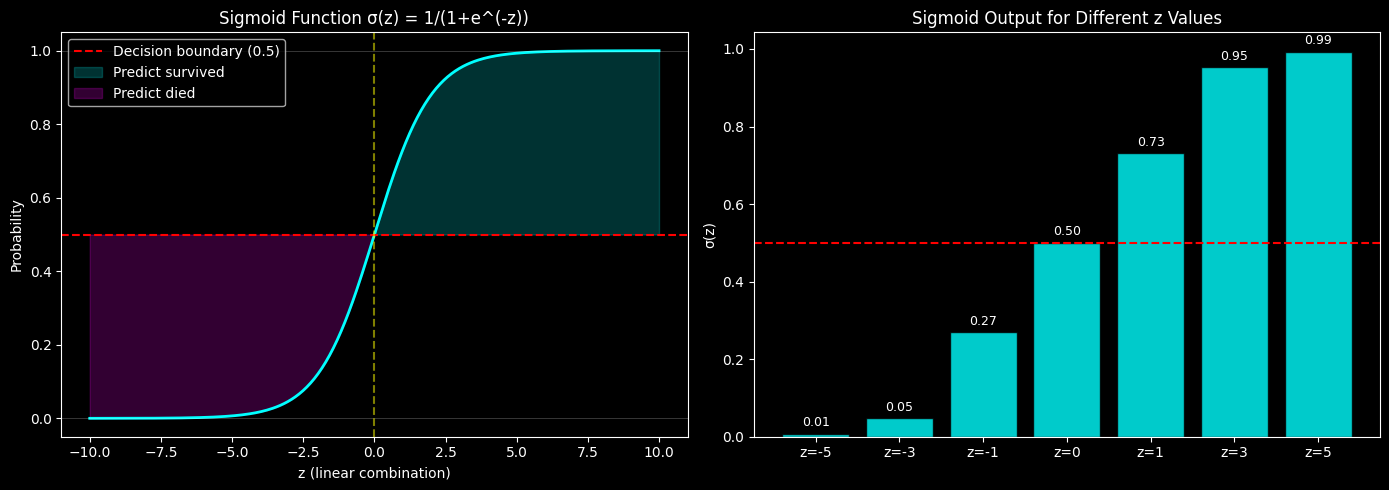


Sigma values:
  z= -5: σ=0.0067 → Died ❌
  z= -3: σ=0.0474 → Died ❌
  z= -1: σ=0.2689 → Died ❌
  z=  0: σ=0.5000 → Died ❌
  z=  1: σ=0.7311 → Survived ✅
  z=  3: σ=0.9526 → Survived ✅
  z=  5: σ=0.9933 → Survived ✅


In [ ]:
print("=" * 55)
print("         THE SIGMOID FUNCTION")
print("=" * 55)
print(
    """
WHY NOT LINEAR REGRESSION FOR CLASSIFICATION?
  Linear regression predicts any number (-∞ to +∞)
  But probability must be between 0 and 1!

SOLUTION: Sigmoid function squashes any number to (0,1)

  σ(z) = 1 / (1 + e^(-z))

WHERE z = β₀ + β₁x₁ + ... (linear combination)

  z → -∞  : σ(z) → 0  (definitely class 0)
  z = 0   : σ(z) = 0.5 (decision boundary)
  z → +∞  : σ(z) → 1  (definitely class 1)
"""
)

# Plot sigmoid
z = np.linspace(-10, 10, 300)
sigmoid = 1 / (1 + np.exp(-z))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sigmoid curve
axes[0].plot(z, sigmoid, color="cyan", linewidth=2)
axes[0].axhline(0.5, color="red", linestyle="--", label="Decision boundary (0.5)")
axes[0].axhline(0, color="white", linewidth=0.5, alpha=0.3)
axes[0].axhline(1, color="white", linewidth=0.5, alpha=0.3)
axes[0].axvline(0, color="yellow", linestyle="--", alpha=0.5)
axes[0].fill_between(
    z,
    sigmoid,
    0.5,
    where=(sigmoid > 0.5),
    alpha=0.2,
    color="cyan",
    label="Predict survived",
)
axes[0].fill_between(
    z,
    sigmoid,
    0.5,
    where=(sigmoid < 0.5),
    alpha=0.2,
    color="magenta",
    label="Predict died",
)
axes[0].set_title("Sigmoid Function σ(z) = 1/(1+e^(-z))")
axes[0].set_xlabel("z (linear combination)")
axes[0].set_ylabel("Probability")
axes[0].legend()
axes[0].set_ylim(-0.05, 1.05)

# Sigmoid values table
z_vals = [-5, -3, -1, 0, 1, 3, 5]
sig_vals = [1 / (1 + np.exp(-z)) for z in z_vals]
axes[1].bar(range(len(z_vals)), sig_vals, color="cyan", edgecolor="black", alpha=0.8)
axes[1].axhline(0.5, color="red", linestyle="--")
axes[1].set_xticks(range(len(z_vals)))
axes[1].set_xticklabels([f"z={z}" for z in z_vals])
axes[1].set_title("Sigmoid Output for Different z Values")
axes[1].set_ylabel("σ(z)")
for i, v in enumerate(sig_vals):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\nSigma values:")
for z_val, s_val in zip(z_vals, sig_vals):
    pred = "Survived ✅" if s_val > 0.5 else "Died ❌"
    print(f"  z={z_val:3d}: σ={s_val:.4f} → {pred}")

## 3. Train Logistic Regression

In [ ]:
print("=" * 55)
print("      TRAINING LOGISTIC REGRESSION")
print("=" * 55)

# Build pipeline
pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(random_state=42, max_iter=1000)),
    ]
)

# Cross-validation
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
print(f"\n5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Train and predict
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]  # probability of survival

print(f"\n--- ALL CLASSIFICATION METRICS ---")
print(f"Accuracy:   {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision:  {precision_score(y_test, y_pred):.4f}")
print(f"Recall:     {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:   {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:    {roc_auc_score(y_test, y_prob):.4f}")
print(f"Log Loss:   {log_loss(y_test, y_prob):.4f}")

print(f"\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=["Died", "Survived"]))

# Show probability predictions for first 10
print(f"\n--- SAMPLE PREDICTIONS ---")
print(f"{'Actual':<10} {'Predicted':<12} {'Prob(Survived)':<16} {'Correct?'}")
print("-" * 50)
for i in range(10):
    actual = y_test.iloc[i]
    pred = y_pred[i]
    prob = y_prob[i]
    correct = "✅" if actual == pred else "❌"
    print(
        f"{'Survived' if actual==1 else 'Died':<10} "
        f"{'Survived' if pred==1 else 'Died':<12} "
        f"{prob:.4f}{'':8} {correct}"
    )

      TRAINING LOGISTIC REGRESSION

5-Fold CV Accuracy: 0.7950 ± 0.0253

--- ALL CLASSIFICATION METRICS ---
Accuracy:   0.8101
Precision:  0.7778
Recall:     0.7101
F1 Score:   0.7424
ROC-AUC:    0.8534
Log Loss:   0.4508

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        Died       0.83      0.87      0.85       110
    Survived       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179


--- SAMPLE PREDICTIONS ---
Actual     Predicted    Prob(Survived)   Correct?
--------------------------------------------------
Died       Died         0.1079         ✅
Died       Died         0.0740         ✅
Survived   Died         0.1154         ❌
Died       Died         0.0596         ✅
Survived   Survived     0.6696         ✅
Survived   Survived     0.6035         ✅
Survived   Survived     0.7581         ✅
Died

## 4. Classification Metrics Deep Dive

In [ ]:
print("=" * 55)
print("    CLASSIFICATION METRICS DEEP DIVE")
print("=" * 55)

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print(
    f"""
CONFUSION MATRIX:
                 Predicted Died  Predicted Survived
Actual Died:          {TN}              {FP}
Actual Survived:      {FN}              {TP}

TRUE NEGATIVES  (TN={TN}): Correctly predicted DIED
FALSE POSITIVES (FP={FP}): Predicted survived, actually DIED
FALSE NEGATIVES (FN={FN}): Predicted died, actually SURVIVED
TRUE POSITIVES  (TP={TP}): Correctly predicted SURVIVED

DERIVED METRICS:
  Accuracy  = (TP+TN)/(TP+TN+FP+FN) = ({TP}+{TN})/179 = {(TP+TN)/179:.4f}
  Precision = TP/(TP+FP)             = {TP}/({TP}+{FP})  = {TP/(TP+FP):.4f}
  Recall    = TP/(TP+FN)             = {TP}/({TP}+{FN})  = {TP/(TP+FN):.4f}
  F1        = 2×(P×R)/(P+R)         = {2*(TP/(TP+FP))*(TP/(TP+FN))/((TP/(TP+FP))+(TP/(TP+FN))):.4f}
"""
)

print("WHEN TO USE WHICH METRIC:")
print(
    """
  Accuracy:  Good when classes are BALANCED
             Bad when imbalanced (79% non-spam → 79% acc doing nothing!)

  Precision: Use when FALSE POSITIVES are costly
             "Don't falsely accuse innocent people"
             Medical: Don't tell healthy people they have cancer

  Recall:    Use when FALSE NEGATIVES are costly
             "Don't miss actual positives"
             Medical: Don't miss actual cancer cases!

  F1:        Use when you need BALANCE of precision & recall
             Good default for imbalanced datasets

  ROC-AUC:   Use when you need RANKING performance
             Best for comparing models overall
"""
)

    CLASSIFICATION METRICS DEEP DIVE

CONFUSION MATRIX:
                 Predicted Died  Predicted Survived
Actual Died:          96              14
Actual Survived:      20              49

TRUE NEGATIVES  (TN=96): Correctly predicted DIED
FALSE POSITIVES (FP=14): Predicted survived, actually DIED
FALSE NEGATIVES (FN=20): Predicted died, actually SURVIVED
TRUE POSITIVES  (TP=49): Correctly predicted SURVIVED

DERIVED METRICS:
  Accuracy  = (TP+TN)/(TP+TN+FP+FN) = (49+96)/179 = 0.8101
  Precision = TP/(TP+FP)             = 49/(49+14)  = 0.7778
  Recall    = TP/(TP+FN)             = 49/(49+20)  = 0.7101
  F1        = 2×(P×R)/(P+R)         = 0.7424

WHEN TO USE WHICH METRIC:

  Accuracy:  Good when classes are BALANCED
             Bad when imbalanced (79% non-spam → 79% acc doing nothing!)

  Precision: Use when FALSE POSITIVES are costly
             "Don't falsely accuse innocent people"
             Medical: Don't tell healthy people they have cancer

  Recall:    Use when FALSE NEGA

## 5. ROC Curve & Threshold Analysis

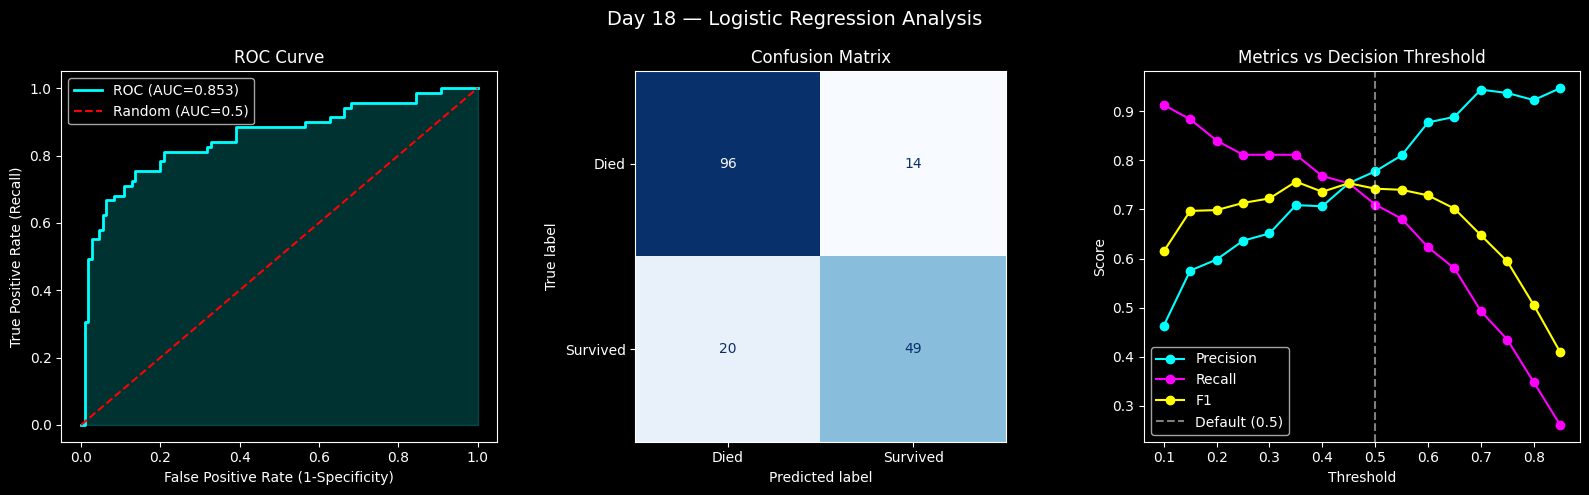


Threshold Analysis:
Threshold    Precision    Recall     F1      
---------------------------------------------
0.10         0.463        0.913      0.615   
0.25         0.636        0.812      0.713   
0.40         0.707        0.768      0.736   
0.55         0.810        0.681      0.740   
0.70         0.944        0.493      0.648   
0.85         0.947        0.261      0.409   


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Day 18 — Logistic Regression Analysis", fontsize=14)

# 1 — ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

axes[0].plot(fpr, tpr, color="cyan", linewidth=2, label=f"ROC (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], color="red", linestyle="--", label="Random (AUC=0.5)")
axes[0].fill_between(fpr, tpr, alpha=0.2, color="cyan")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate (1-Specificity)")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].legend()

# 2 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Died", "Survived"])
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix")

# 3 — Precision/Recall vs Threshold
thresh_range = np.arange(0.1, 0.9, 0.05)
precisions, recalls, f1s = [], [], []
for thresh in thresh_range:
    y_pred_t = (y_prob >= thresh).astype(int)
    if y_pred_t.sum() > 0:
        precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
        recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
        f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    else:
        precisions.append(0)
        recalls.append(0)
        f1s.append(0)

axes[2].plot(thresh_range, precisions, "o-", color="cyan", label="Precision")
axes[2].plot(thresh_range, recalls, "o-", color="magenta", label="Recall")
axes[2].plot(thresh_range, f1s, "o-", color="yellow", label="F1")
axes[2].axvline(0.5, color="white", linestyle="--", alpha=0.5, label="Default (0.5)")
axes[2].set_title("Metrics vs Decision Threshold")
axes[2].set_xlabel("Threshold")
axes[2].set_ylabel("Score")
axes[2].legend()

plt.tight_layout()
plt.show()

print("\nThreshold Analysis:")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<10} {'F1':<8}")
print("-" * 45)
for i, t in enumerate(thresh_range[::3]):
    idx = list(thresh_range).index(t)
    print(f"{t:<12.2f} {precisions[idx]:<12.3f} {recalls[idx]:<10.3f} {f1s[idx]:<8.3f}")

## 6. Key Takeaways — Day 18 🎯

### Why Logistic Regression (not Linear) for Classification?
- Linear regression predicts -∞ to +∞ — probabilities must be 0 to 1!
- Sigmoid function: σ(z) = 1/(1+e^(-z)) squashes output to (0,1)
- z < 0 → probability < 0.5 → predict class 0
- z > 0 → probability > 0.5 → predict class 1
- z = 0 → exactly 0.5 → decision boundary

### Our Model Results
- Accuracy:  81.0% — 8 in 10 correct
- Precision: 77.8% — when predicting survival, right 78% of time
- Recall:    71.0% — catch 71% of actual survivors
- F1 Score:  74.2% — harmonic mean of precision and recall
- ROC-AUC:   85.3% — excellent ranking performance!
- Log Loss:  0.451 — lower is better

### The Confusion Matrix
| | Predicted Died | Predicted Survived |
|---|---|---|
| **Actual Died** | 96 (TN) ✅ | 14 (FP) ❌ |
| **Actual Survived** | 20 (FN) ❌ | 49 (TP) ✅ |

### When to Use Which Metric
- **Accuracy:** Balanced classes only
- **Precision:** When false positives are costly (spam filter)
- **Recall:** When false negatives are costly (cancer detection)
- **F1:** Default for imbalanced datasets
- **ROC-AUC:** Comparing models, threshold-independent

### Threshold Tuning
- Default threshold = 0.5
- Lower threshold → higher recall, lower precision
- Higher threshold → higher precision, lower recall
- Threshold 0.10: Recall=91.3% (catch almost everyone!)
- Threshold 0.85: Precision=94.7% (only very confident predictions)
- Best F1 at threshold ≈ 0.40 for this dataset!

### sklearn Functions
- `LogisticRegression(random_state=42, max_iter=1000)`
- `pipeline.predict_proba(X)[:, 1]` — survival probabilities
- `roc_auc_score(y_true, y_prob)` — AUC score
- `roc_curve(y_true, y_prob)` — FPR, TPR, thresholds
- `log_loss(y_true, y_prob)` — log loss
- `confusion_matrix(y_true, y_pred)` — TN, FP, FN, TP
- `classification_report(y_true, y_pred)` — full metrics table